
# Actividad: Regresión Logística con el Dataset del Titanic

**Nombre del estudiante:** Fernanda Lizeth Zambrano Gudiño
---

## 1. Carga y exploración inicial



In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el dataset
df = pd.read_csv("titanic_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'titanic_clean.csv'

In [ ]:
# Explorar las primeras filas
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked_Q,embarked_S,familysize,isalone,title_Miss,title_Mr,title_Mrs,title_Rare,fare_log,familysize_log
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.00,0,0,24160,211.3375,0,1,1,1,1,0,0,0,5.358177,0.693147
1,1,1,"Allison, Master. Hudson Trevor",1,0.92,1,2,113781,151.5500,0,1,4,0,0,0,0,0,5.027492,1.609438
2,1,0,"Allison, Miss. Helen Loraine",0,2.00,1,2,113781,151.5500,0,1,4,0,1,0,0,0,5.027492,1.609438
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.00,1,2,113781,151.5500,0,1,4,0,0,1,0,0,5.027492,1.609438
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.00,1,2,113781,151.5500,0,1,4,0,0,0,1,0,5.027492,1.609438


In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pclass          1308 non-null   int64  
 1   survived        1308 non-null   int64  
 2   name            1308 non-null   object 
 3   sex             1308 non-null   int64  
 4   age             1308 non-null   float64
 5   sibsp           1308 non-null   int64  
 6   parch           1308 non-null   int64  
 7   ticket          1308 non-null   object 
 8   fare            1308 non-null   float64
 9   embarked_Q      1308 non-null   int64  
 10  embarked_S      1308 non-null   int64  
 11  familysize      1308 non-null   int64  
 12  isalone         1308 non-null   int64  
 13  title_Miss      1308 non-null   int64  
 14  title_Mr        1308 non-null   int64  
 15  title_Mrs       1308 non-null   int64  
 16  title_Rare      1308 non-null   int64  
 17  fare_log        1308 non-null   f

In [ ]:
# Verificar valores faltantes
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0
embarked_Q,0


**Interpretación:**

En el datset se ve que hay tanto variables categóricas como numéricas previamente transformadas. También podemos ver que no hay valores nulos ya que el dataset fue previamente limpiado. Tenemos 1308 obeservaciones y 19 variables en donde hay dos categorias llamadas "name" y "ticket" las cuales no son adecuadas para el modelo

## 2. División de datos

Divide el dataset en conjuntos de **entrenamiento (80%)** y **prueba (20%)** utilizando `train_test_split` de scikit-learn.

**Requisitos:**
- Usa `random_state=42` para reproducibilidad
- Usa `stratify` para mantener la proporción de clases en ambos conjuntos
- Separa las características (X) de la variable objetivo (y)

**Método recomendado:** `sklearn.model_selection.train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['survived', 'name', 'ticket'], axis=1)
y = df['survived']

# Separar características (X) y variable objetivo (y)

In [ ]:
# Dividir en entrenamiento y validacion
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Verificar las dimensiones de los conjuntos
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1046, 16)
(262, 16)
(1046,)
(262,)


In [ ]:
# Verificar la proporción de clases en ambos conjuntos
print("Proporción original:")
print(y.value_counts(normalize=True))

print("\nProporción en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción en prueba:")
print(y_test.value_counts(normalize=True))

Proporción original:
survived
0    0.617737
1    0.382263
Name: proportion, dtype: float64

Proporción en entrenamiento:
survived
0    0.617591
1    0.382409
Name: proportion, dtype: float64

Proporción en prueba:
survived
0    0.618321
1    0.381679
Name: proportion, dtype: float64


## 3. Normalización/Estandarización

Estandariza las variables numéricas para que tengan media 0 y desviación estándar 1.

**IMPORTANTE: para prevenir fuga de datos**
1. **Ajusta (fit)** el scaler **SOLO** con los datos de entrenamiento
2. **Transforma (transform)** tanto los datos de entrenamiento como los de prueba usando el mismo scaler ajustado

Esto evita que información del conjunto de prueba "se filtre" al entrenamiento.

**Método recomendado:** `sklearn.preprocessing.StandardScaler` ó `sklearn.preprocessing.MinMaxScaler`

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
# Crear el scaler

In [ ]:
# Ajustar el scaler SOLO con datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
# Transformar ambos conjuntos con el mismo scaler
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Verificar que la estandarización funcionó correctamente (si fue el caso)
# (media ≈ 0 y desviación estándar ≈ 1 en el conjunto de entrenamiento)
# O maxima 1 y minimo 0 si se trata de MinMaxScaler

print("Media (train):")
print(np.mean(X_train_scaled, axis=0))

print("\nDesviación estándar (train):")
print(np.std(X_train_scaled, axis=0))

Media (train):
[ 1.47746697e-16  4.16068285e-17  2.54735684e-17 -2.54735684e-17
 -3.82103527e-18  1.52841411e-17  6.79295158e-18 -1.47746697e-16
 -4.92488990e-17  2.54735684e-17  5.00980179e-17  8.49118948e-18
 -1.69823790e-17 -7.04768727e-17 -1.04441631e-16 -1.52841411e-17]

Desviación estándar (train):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Modelo base de regresión logística

Entrena un modelo de regresión logística básico (sin regularización especial) y evalúa su desempeño inicial.

**Método recomendado:** `sklearn.linear_model.LogisticRegression`

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train_scaled, y_train)

# Crear y entrenar el modelo base
# Usa max_iter=1000 para asegurar convergencia

LogisticRegression(max_iter=1000)

In [ ]:
# Hacer predicciones en entrenamiento y validacion

# Predicciones en entrenamiento
y_train_pred = modelo.predict(X_train_scaled)

# Predicciones en prueba (validación)
y_test_pred = modelo.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

# Accuracy en entrenamiento
acc_train = accuracy_score(y_train, y_train_pred)

# Accuracy en prueba
acc_test = accuracy_score(y_test, y_test_pred)

print("Accuracy entrenamiento:", acc_train)
print("Accuracy prueba:", acc_test)

Accuracy entrenamiento: 0.8087954110898662
Accuracy prueba: 0.8435114503816794


**Interpretación:**

¿Hay alguna evidencia de sobreajuste? ¿Por qué?

No hay sobreajuste porque los datos son similares y la diferencia es muy pequeña

## 5. Validación cruzada

Implementa **validación cruzada con k=5 folds** para evaluar la estabilidad del modelo y obtener una estimación más robusta de su desempeño.

**Requisitos:**
- Calcula el accuracy promedio y su desviación estándar
- Interpreta los resultados: ¿el modelo es estable entre folds?

**Método recomendado:** `sklearn.model_selection.cross_val_score`

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='accuracy')

In [ ]:
# Mostrar los scores de cada fold
print("Accuracy por fold:", cv_scores)

Accuracy por fold: [0.8047619  0.77990431 0.77511962 0.79904306 0.83253589]


In [ ]:
# Calcular media y desviación estándar
print("Accuracy promedio:", cv_scores.mean())
print("Desviación estándar:", cv_scores.std())

Accuracy promedio: 0.7982729551150605
Desviación estándar: 0.020445695028060425


**Interpretación:**

¿El modelo es estable?

Si porque la desviación estándar es estable y los valores de accuracy en cada fold son similares

## 6. Control de sobreajuste con regularización

Experimenta con diferentes valores del parámetro de regularización `C` para controlar el sobreajuste.

**Contexto teórico:**
- El parámetro `C` es el **inverso** de la fuerza de regularización
- `C` pequeño → Mayor regularización → Modelo más simple
- `C` grande → Menor regularización → Modelo más complejo
- El parámetro `penalty` define el tipo de regularización: `'l1'` (Lasso), `'l2'` (Ridge), o `ElasticNet` (una combinación entre ambos=

**Requisitos:**
- Prueba al menos 5 valores diferentes de `C`: [0.001, 0.01, 0.1, 1, 10, 100]
- Usa `penalty='l2'` (regularización Ridge)
- Compara el desempeño en entrenamiento vs prueba para cada valor
- Identifica el mejor valor de `C`
- Grafica los resultados

In [ ]:
# Definir valores de C a probar
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

In [ ]:
# Entrenar modelos con diferentes valores de C
# Guardar scores de entrenamiento y prueba
# Listas para guardar scores
train_acc = []
test_acc = []

for C in C_values:
    modelo = LogisticRegression(C=C, penalty='l2', max_iter=1000)

    modelo.fit(X_train_scaled, y_train)


    y_train_pred = modelo.predict(X_train_scaled)
    y_test_pred = modelo.predict(X_test_scaled)


    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

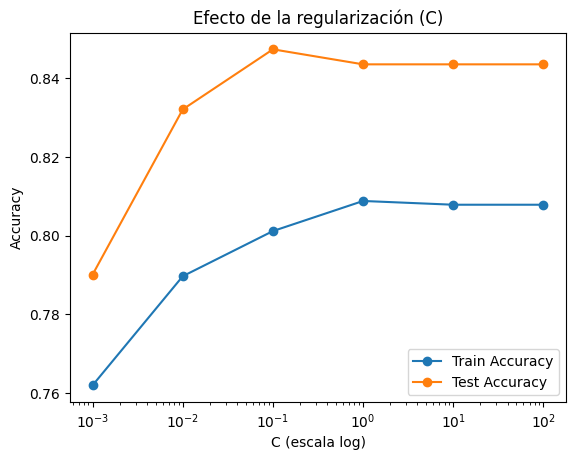

In [ ]:
# Graficar los resultados
plt.figure()
plt.plot(C_values, train_acc, marker='o', label='Train Accuracy')
plt.plot(C_values, test_acc, marker='o', label='Test Accuracy')

plt.xscale('log')
plt.xlabel('C (escala log)')
plt.ylabel('Accuracy')
plt.title('Efecto de la regularización (C)')
plt.legend()

plt.show()

In [ ]:
# Identificar el mejor valor de C
best_index = test_acc.index(max(test_acc))
best_C = C_values[best_index]

print("Mejor valor de C:", best_C)


Mejor valor de C: 0.1


**Interpretación:**
¿Qué valor de C funciona mejor?¿Por qué?¿Observas sobreajuste en algún caso?

El valor de C que funciona mejor es el 0.1 porque en la gráfica se puede que el accuracy de prueba alcanza su valor más alto y no hay sobreajuste pero si hay valores altos en C

## 7. Evaluación exhaustiva del modelo

Evalúa el mejor modelo utilizando múltiples métricas de clasificación.

**Métricas a calcular:**

a) **Matriz de confusión** - Visualízala con un heatmap

b) **Reporte de clasificación completo** - Incluye precision, recall, f1-score para cada clase

c) **Métricas individuales:** Accuracy, Precision, Recall, F1-Score

d) **Curva ROC y AUC**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

In [ ]:
# Entrenar el modelo final con el mejor valor de C
best_model = LogisticRegression(C=0.1, penalty='l2', max_iter=1000)

best_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, max_iter=1000)

In [ ]:
# Hacer predicciones

y_pred = best_model.predict(X_test_scaled)



### 7a. Matriz de confusión

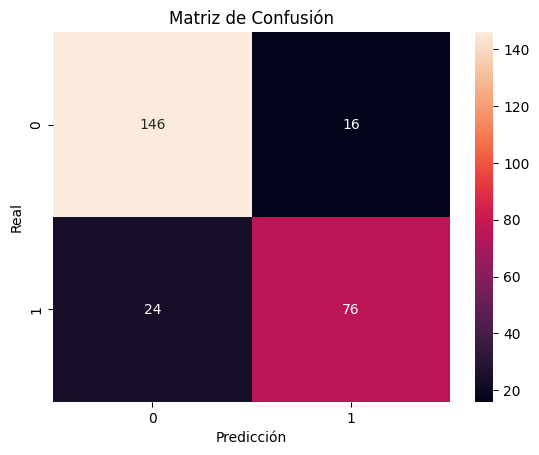

In [ ]:
# Calcular y visualizar la matriz de confusión

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

### 7b. Reporte de clasificación

In [ ]:
# Mostrar el reporte de clasificación completo

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       162
           1       0.83      0.76      0.79       100

    accuracy                           0.85       262
   macro avg       0.84      0.83      0.84       262
weighted avg       0.85      0.85      0.85       262



### 7c. Métricas individuales

In [ ]:
# Calcular y mostrar métricas individuales
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Accuracy: 0.8473282442748091
Precision: 0.8260869565217391
Recall: 0.76
F1-Score: 0.7916666666666666


### 7d. Curva ROC y AUC

In [ ]:
# Obtener probabilidades predichas
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

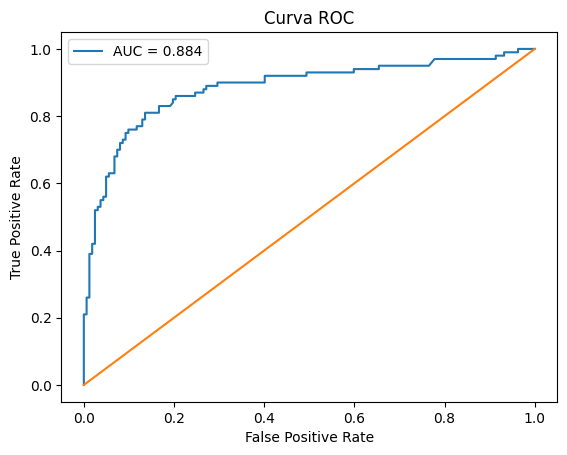

AUC: 0.8842901234567901


In [ ]:
# Graficar la curva ROC
from sklearn.metrics import auc
# Calcular AUC
roc_auc = auc(fpr, tpr)

# Graficar curva ROC
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1])  # línea base
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()

plt.show()

print("AUC:", roc_auc)

**Interpretación:**

1. ¿Qué clase predice mejor el modelo: sobrevivientes o no sobrevivientes?

La clase 0 predice mejor porque detecta mejor a los que no sobrevivieron que a los que si

2. ¿Cuál es el trade-off entre precision y recall?

El modelo prefiere no equivocarse a decir al decir que alguien sobrevive aunque eso implique dejar pasar a algunos sobrevivientes


3. ¿Qué tan bueno es el AUC obtenido? (Pista: AUC = 0.5 es aleatorio, AUC = 1.0 es perfecto)

Es muy bueno porque se acerca mucho a 1.0

4. ¿Qué errores comete más el modelo: falsos positivos o falsos negativos?

Comete más falsos negativos

## 8. Análisis de características importantes (opcional)

Identifica las características más importantes para la predicción analizando los coeficientes del modelo.

In [ ]:
# Crear un DataFrame con las características y sus coeficientes

In [ ]:
# Visualizar las características más importantes

**Interpretación:**

¿Qué característica tienen mayor impacto en la predicción? ¿Tiene sentido con lo que sabemos de este caso del hundimiento del Titanic?

## Conclusiones finales

Sus conclusiones podrían incluir discusión sobre lo siguiente.

1. **Desempeño del modelo:**

2. **Características más importantes:**

3. **Limitaciones observadas:**

4. **Posibles mejoras:**

El modelo de regresión logística presenta un buen desempeño en general con un UAC de 0.88 lo que significa que hay una alta capacidad para distinguir entre pasajeros que sobrevivieron y los que no. Las características más importantes en la predicción fueron el sexo, la clase del pasajero, tarifa y edad ya que reflejaron que factores son los implicados para la supervivencia de los pasajeros